## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [1]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

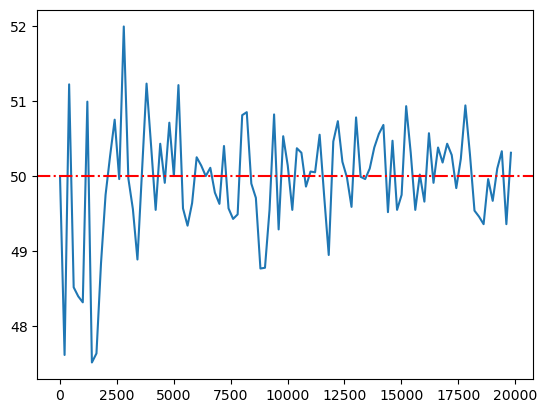

In [2]:
def lancio_moneta(n):
    lancio = np.random.choice(a=['testa','croce'], size=n)
    return(round(lancio[lancio =='testa'].size/n*100,2))


lis = [lancio_moneta(n) for n in range(10,20001,20000//100)]
x = [n for n in range(10,20001,20000//100)]

plt.plot(x,lis)
plt.axhline(50,color='red',linestyle='dashdot')
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [3]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#1.Quante righe e colonne ha il dataset?
print(df.shape)

(891, 12)


In [5]:
#2.Controlla quanti valori mancanti ci sono per colonna
print(pd.isnull(df).sum(axis=0))

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
#3.Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
df['Embarked']=df['Embarked'].fillna(df.Embarked.value_counts().idxmax())

In [7]:
#4.Controlla se ci sono righe duplicate
df.duplicated().sum()

np.int64(0)

In [8]:
#5.Calcola l'età media dei passeggeri per ogni classe (`Pclass`),
#  se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
print(round(df.groupby('Pclass')['Age'].mean(),1))
df['Age'] = df['Age'].fillna(round(df.Age.mean(),1))

Pclass
1    38.2
2    29.9
3    25.1
Name: Age, dtype: float64


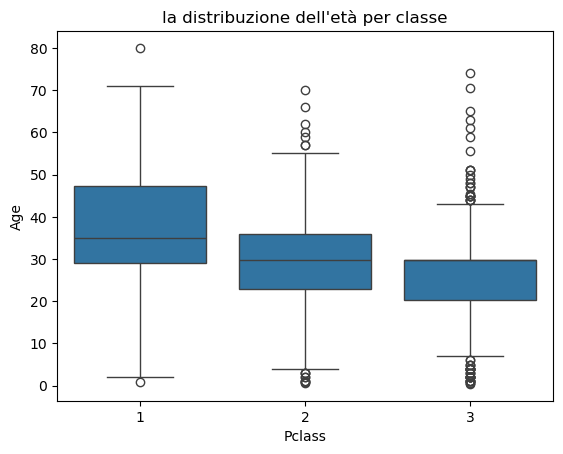

In [9]:
#6.Visualizza la distribuzione dell'età per classe

sns.boxplot(data=df, x='Pclass', y='Age')
plt.title('la distribuzione dell\'età per classe')
plt.show()



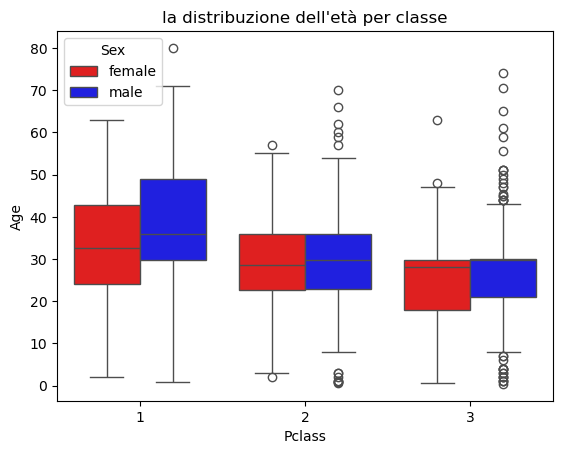

In [10]:
sns.boxplot(data=df, x='Pclass', y='Age',hue='Sex',palette=['red','blue'])
plt.title('la distribuzione dell\'età per classe')
plt.show()


## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [12]:
#1.Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
df.species.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [21]:
#2.Calcola la lunghezza e la larghezza media dei petali per specie
print(df.groupby('species')[['petal_length','petal_width']].mean())

            petal_length  petal_width
species                              
setosa             1.462        0.246
versicolor         4.260        1.326
virginica          5.552        2.026


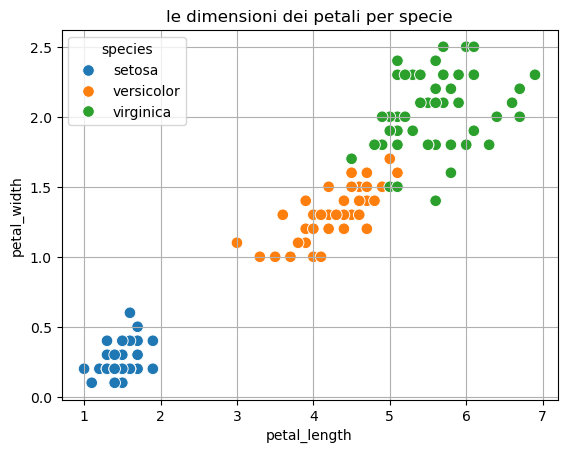

In [ ]:
#3.Visualizza le dimensioni dei petali per specie (scatterplot)
# plt.scatter(df.species,df.petal_length,label='petal length')
# plt.scatter(df.species,df.petal_width,label='petal width')
sns.scatterplot(
    data=df,
    x= 'petal_length',
    y='petal_width',
    hue='species',
    s=70,
)
plt.title('le dimensioni dei petali per specie')
plt.grid(True)  # Aggiunge una griglia per migliorare la leggibilità
plt.show()

In [29]:
#4.Crea una nuova colonna per l'area del petalo e analizzala
df['petal_area'] = df.petal_length*df.petal_width
df.petal_area.describe()

count    150.000000
mean       5.794067
std        4.712390
min        0.110000
25%        0.420000
50%        5.615000
75%        9.690000
max       15.870000
Name: petal_area, dtype: float64

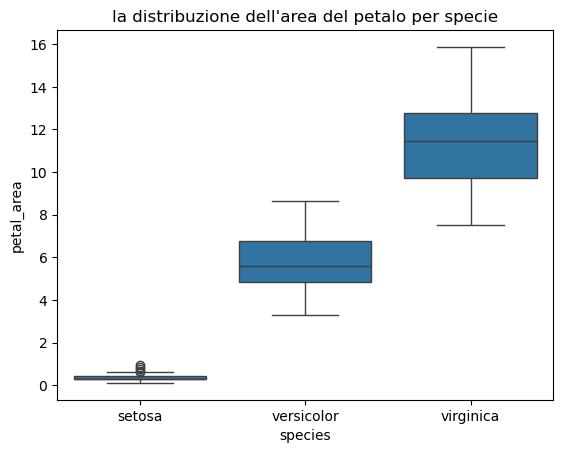

In [32]:
#5.Grafico della distribuzione dell'area del petalo per specie (boxplot)
sns.boxplot(data=df, x='species', y='petal_area')
plt.title("la distribuzione dell'area del petalo per specie")
plt.show()